In [4]:
# Code to import libraries as you need in this assessment, e.g.,
import pandas as pd
import os
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import KeyedVectors
from scipy.sparse import coo_matrix, issparse
import warnings
from gensim.models import FastText
warnings.filterwarnings("ignore")

In [5]:
VOCAB_PATH = "./data/vocab.txt"
DATASET_PATH = "./data/processed.csv"
BOW_PATH = "./data/count_vectors.txt"
UNWEIGHTED_PATH = "./data/unweighted_vectors.txt"
WEIGHTED_PATH = "./data/weighted_vectors.txt"
GLOVE_PATH = "/Users/nhan.ngo/rmit/RMIT-Advanced-Programming-for-Data-Science/archive/glove.6B.300d.txt"
OUTPUT_PATH = "./data/unweighted_vectors.txt"


In [6]:
def load_vocab(path: str) -> dict:
    vocab: dict = {}
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if ":" in line:
                word, idx = line.rsplit(":", 1)
                vocab[word.strip()] = int(idx.strip())
    return vocab  # {"absolutely": 1, "feels": 42, …}

In [7]:
def build_count_vector(review_text: str, vocab: dict[str, int]) -> dict[int, int]:
    tokens = review_text.split() # already cleaned — just split on whitespace
    counts: Counter = Counter()

    for token in tokens:
        if token in vocab:
            counts[vocab[token]] += 1 # accumulate by vocab index

    return dict(counts)

In [8]:
def make_bow_line(row_idx: int, count_vector: dict):
    """ Relied on the requirement from assignment
        ```
        count_vectors.txt This file stores the sparse count vector representation of cosmetics/beauty
            reviews in the following format. Each line of this file corresponds to one review. It starts with
            a ‘#’ key followed by the index of the item review, and a comma ‘,’. The rest of the line is the
            sparse representation of the corresponding description in the form of
            word_integer_index:word_freq separated by comma.
        ```
    """
    if not count_vector:
        return f"#{row_idx},"
    pairs: str = ",".join(f"{idx}:{freq}" for idx, freq in sorted(count_vector.items()))
    return f"#{row_idx},{pairs}"

In [9]:
def make_bows(reviews: str, vocab: dict, path: str):
    content: str = ""
    for i, r in enumerate(reviews):
        r = str(r) # Cast type
        count_vector: dict = build_count_vector(r, vocab)
        line: str = make_bow_line(i, count_vector) + "\n"
        content +=line
    with open(path, "w", encoding="utf-8") as out:
        out.write(content)
    print(f"Saved to {path}")

In [10]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, roc_auc_score
from xgboost import XGBClassifier
svc_scoring = {
    "accuracy": "accuracy",
    "f1": "f1",
    "roc_auc": make_scorer(roc_auc_score, response_method="decision_function"),
}


In [11]:
vocab: dict = load_vocab(VOCAB_PATH)
df = pd.read_csv(DATASET_PATH)
df["processed_review_text"] = df["processed_review_text"].fillna('')

In [10]:
# Bag of word
make_bows(reviews=df["processed_review_text"].values, vocab=vocab, path=BOW_PATH)

Saved to ./data/count_vectors.txt


In [11]:
ft_sentences = [str(s).split() for s in df["processed_review_text"]]

In [12]:
ft_model = FastText(
    sentences=ft_sentences,
    vector_size=300,
    window=5,
    min_count=5,
    workers=4,
)

In [12]:
def doc_vector_unweighted_fasttext(wv, text: str, dim: int) -> np.ndarray:
    """Mean of token vectors; FastText uses subword n-grams so get_vector works for OOV."""
    text = str(text).strip()
    if not text:
        return np.zeros(dim, dtype=np.float32)
    vecs = [wv.get_vector(t, norm=False) for t in text.split()]
    if not vecs:
        return np.zeros(dim, dtype=np.float32)
    return np.mean(np.vstack(vecs), axis=0).astype(np.float32)


def embed_all_unweighted_fasttext(wv, reviews: list[str], dim: int) -> np.ndarray:
    out = np.zeros((len(reviews), dim), dtype=np.float32)
    for i, r in enumerate(reviews):
        out[i] = doc_vector_unweighted_fasttext(wv, r, dim)
    return out


def save_vectors_txt(path: str, embeddings: np.ndarray) -> None:
    """One line per row: #idx,v1,v2,... (same format as task2_3.ipynb)."""
    with open(path, "w", encoding="utf-8") as f:
        for idx, vec in enumerate(embeddings):
            vec_str = ",".join(f"{v:.6f}" for v in vec)
            f.write(f"#{idx},{vec_str}\n")


def tfidf_weighted_fasttext(reviews: list[str], wv, dim: int, vocab: dict) -> np.ndarray:
    """TF-IDF weighted average of token vectors (Task 1 vocab), using FastText vectors."""
    vectorizer = TfidfVectorizer(
        analyzer=lambda s: str(s).split(),
        lowercase=False,
        vocabulary=vocab,
    )
    X = vectorizer.fit_transform(reviews)
    terms = vectorizer.get_feature_names_out()
    n_docs = X.shape[0]
    out = np.zeros((n_docs, dim), dtype=np.float32)
    for i in range(n_docs):
        row = X.getrow(i)
        if row.nnz == 0:
            continue
        acc = np.zeros(dim, dtype=np.float64)
        wsum = 0.0
        for idx, w in zip(row.indices, row.data):
            t = terms[idx]
            acc += w * wv.get_vector(str(t), norm=False)
            wsum += w
        if wsum > 0:
            out[i] = (acc / wsum).astype(np.float32)
    return out

In [16]:
reviews: list[str] = df["processed_review_text"].fillna("").astype(str).tolist()
wv_ft = ft_model.wv
dim_ft: int = int(wv_ft.vector_size)

vectors_unweighted: np.ndarray = embed_all_unweighted_fasttext(wv_ft, reviews, dim_ft)
save_vectors_txt(UNWEIGHTED_PATH, vectors_unweighted)
print(f"Unweighted document vectors → {UNWEIGHTED_PATH} shape={vectors_unweighted.shape}")

vectors_weighted: np.ndarray = tfidf_weighted_fasttext(reviews, wv_ft, dim_ft, vocab)
save_vectors_txt(WEIGHTED_PATH, vectors_weighted)
print(f"Weighted (TF-IDF) document vectors → {WEIGHTED_PATH} shape={vectors_weighted.shape}")

Unweighted document vectors → ./data/unweighted_vectors.txt shape=(61284, 300)
Weighted (TF-IDF) document vectors → ./data/weighted_vectors.txt shape=(61284, 300)


## Task 3. Clothing Review Classification

In [11]:
df.head()

,product_id,brand_name,review_id,review_title,review_text,author,review_date,review_rating,is_a_buyer,product_title,price,avg_product_rating,product_rating_count,product_tags,product_url,processed_review_text
0,781070,Olay,16752142,Worth buying 50g one,Works as it claims. Could see the difference f...,Ashton Dsouza,23/01/2021 15:17,5.0,True,Olay Ultra Lightweight Moisturiser: Luminous W...,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...,work claim difference day play cleanser result
1,781070,Olay,14682550,Best cream to start ur day,It does what it claims . Best thing is it smoo...,Amrit Neelam,07/09/2020 15:30,5.0,True,Olay Ultra Lightweight Moisturiser: Luminous W...,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...,claim thing smoothens soft
2,781070,Olay,15618995,perfect for summers dry for winters,I have been using this product for months now....,Sanchi Gupta,13/11/2020 12:24,4.0,True,Olay Ultra Lightweight Moisturiser: Luminous W...,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...,using month combination oily greasy absorbs qu...
3,781070,Olay,13474509,Not a moisturizer,"i have an oily skin, while this whip acts as a...",Ruchi Shah,14/06/2020 11:56,3.0,True,Olay Ultra Lightweight Moisturiser: Luminous W...,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...,oily whip act great base primer smoothens mois...
4,781070,Olay,16338982,Average,It's not that good. Please refresh try for oth...,Sukanya Sarkar,22/12/2020 15:24,2.0,True,Olay Ultra Lightweight Moisturiser: Luminous W...,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...,please refresh try


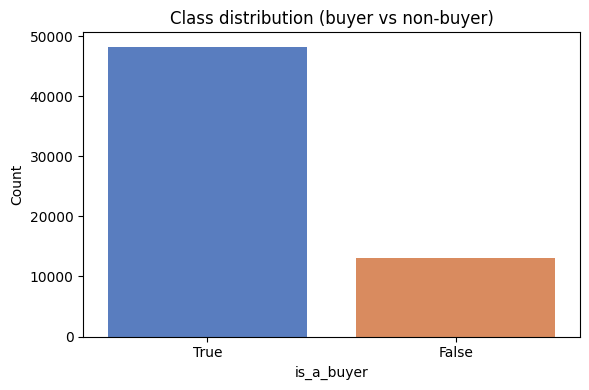

In [13]:
buyer_counts = df["is_a_buyer"].value_counts()
buyer_counts

buyer_plot = (
    buyer_counts.rename_axis("is_a_buyer")
    .reset_index(name="count")
    .astype({"is_a_buyer": str})
)
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(
    data=buyer_plot,
    x="is_a_buyer",
    y="count",
    hue="is_a_buyer",
    palette="muted",
    legend=False,
    ax=ax,
)
ax.set_xlabel("is_a_buyer")
ax.set_ylabel("Count")
ax.set_title("Class distribution (buyer vs non-buyer)")
plt.tight_layout()
plt.show()


In [14]:
def parse_review_vectors_txt(path: str) -> np.ndarray:
    """Load Task 2 dense vectors: each line is ``#row_index,v1,v2,...`` (see ``save_vectors_txt``).

    Returns a 2-D ``numpy.ndarray`` of shape ``(n_samples, n_features)``. You can attach it to a
    dataframe as:

    - one column of per-row vectors: ``df[name] = list(X)`` (object column of 1-D arrays), or
    - many numeric columns: ``pd.concat([df, pd.DataFrame(X, columns=[f"{name}_{i}" for i in range(X.shape[1])])], axis=1)``.
    """
    indexed: list[tuple[int, np.ndarray]] = []
    with open(path, encoding="utf-8") as f:
        for raw in f:
            line = raw.strip()
            if not line:
                continue
            if not line.startswith("#"):
                raise ValueError(f"Expected line starting with '#', got {line[:48]!r}...")
            comma = line.index(",")
            row_idx = int(line[1:comma])
            rest = line[comma + 1 :]
            if not rest.strip():
                vec = np.empty(0, dtype=np.float64)
            else:
                vec = np.fromstring(rest, sep=",", dtype=np.float64)
            indexed.append((row_idx, vec))
    if not indexed:
        raise ValueError(f"No vector rows found in {path!r}")
    indexed.sort(key=lambda t: t[0])
    row_indices = [i for i, _ in indexed]
    if row_indices != list(range(len(row_indices))):
        raise ValueError(
            f"Vector indices must be contiguous 0..n-1; fix {path!r} or match df row order to Task 2."
        )
    dim = indexed[0][1].size
    if dim == 0:
        raise ValueError("Vectors have dimension 0.")
    for i, vec in indexed:
        if vec.size != dim:
            raise ValueError(f"Row #{i}: expected length {dim}, got {vec.size}")
    X = np.stack([v for _, v in indexed], axis=0)
    return np.asarray(X, dtype=np.float64)


def parse_count_vectors_txt(
    path: str,
    n_features: int | None = None,
    *,
    dtype=np.float32,
    as_sparse: bool = False,
):
    """Load ``count_vectors.txt``: each line ``#row_index,word_idx:count,...`` (sparse bag-of-words).

    Default returns a dense ``(n_samples, n_features)`` array (``df[name] = list(X)``).
    Use ``as_sparse=True`` for CSR — avoids allocating full dense BoW RAM; suits LR + ``TruncatedSVD``.

    If ``n_features`` is ``None``, it is inferred as ``max_word_index + 1`` over all lines.
    """

    rows: list[int] = []
    cols: list[int] = []
    data: list[float] = []
    seen_rows: list[int] = []
    max_col = -1

    with open(path, encoding="utf-8") as f:
        for raw in f:
            line = raw.strip()
            if not line:
                continue
            if not line.startswith("#"):
                raise ValueError(f"Expected '#', got {line[:48]!r}...")
            comma = line.index(",")
            row_idx = int(line[1:comma])
            seen_rows.append(row_idx)
            rest = line[comma + 1 :].strip()
            if rest:
                for part in rest.split(","):
                    part = part.strip()
                    if not part or ":" not in part:
                        continue
                    w_s, c_s = part.split(":", 1)
                    w_i = int(w_s)
                    cnt = float(c_s)
                    rows.append(row_idx)
                    cols.append(w_i)
                    data.append(cnt)
                    max_col = max(max_col, w_i)

    if not seen_rows:
        raise ValueError(f"No rows found in {path!r}")

    seen_rows_sorted = sorted(seen_rows)
    if seen_rows_sorted != list(range(len(seen_rows_sorted))):
        raise ValueError(
            f"Row indices must be 0..n-1 without gaps; check {path!r} matches Task 2 / df order."
        )

    n_rows = len(seen_rows_sorted)
    n_feat = n_features if n_features is not None else (max_col + 1)
    if max_col >= n_feat:
        raise ValueError(f"Word index {max_col} >= n_features ({n_feat}); increase n_features or fix vocab.")

    X_sparse = coo_matrix((data, (rows, cols)), shape=(n_rows, n_feat), dtype=np.float64)
    if as_sparse:
        return X_sparse.tocsr()
    X_dense = X_sparse.toarray()
    return np.asarray(X_dense, dtype=dtype)


def prepare_train_data(
    df: pd.DataFrame,
    feature_cols: list[str],
    target_col: str,
) -> tuple[np.ndarray, np.ndarray]:
    """Build ``X`` from ``feature_cols`` and ``y`` from ``target_col`` (same row order as ``df``).

    Also handles vector/object feature columns (e.g. ``vector_review`` where each cell is a 1-D ndarray)
    by expanding them into numeric feature dimensions.
    """
    missing_x = [c for c in feature_cols if c not in df.columns]
    if missing_x:
        raise ValueError(f"Missing feature column(s): {missing_x}")
    if target_col not in df.columns:
        raise ValueError(f"Missing target column: {target_col!r}")
    if not feature_cols:
        raise ValueError("feature_cols must contain at least one column name.")

    X_raw = df.loc[:, feature_cols].to_numpy()

    # Case: single object column where each row stores a vector/list (e.g. feature_cols=["vector_review"]).
    if X_raw.ndim == 2 and X_raw.shape[1] == 1 and X_raw.dtype == object:
        first = X_raw[0, 0]
        if isinstance(first, (list, tuple, np.ndarray)):
            X = np.vstack([np.asarray(v, dtype=np.float64).ravel() for v in X_raw[:, 0]])
        else:
            X = np.asarray(X_raw, dtype=np.float64)
    else:
        # General case: if any selected feature column stores vectors, expand them and concatenate.
        blocks: list[np.ndarray] = []
        for col in feature_cols:
            col_values = df[col].to_numpy()
            first = col_values[0]
            if isinstance(first, (list, tuple, np.ndarray)):
                block = np.vstack([np.asarray(v, dtype=np.float64).ravel() for v in col_values])
            else:
                block = np.asarray(col_values, dtype=np.float64).reshape(-1, 1)
            blocks.append(block)
        X = np.hstack(blocks)

    y = df[target_col].to_numpy().reshape(-1)
    return X, y


## Only Review Vectors

In [ ]:
def sanitize_X_y(X, y, clip_value=1e6):
    y = np.asarray(y).reshape(-1)
    if issparse(X):
        return X, y
    X = np.asarray(X, dtype=np.float64)
    # replace inf with nan, then fill nan by column median
    X[~np.isfinite(X)] = np.nan
    col_median = np.nanmedian(X, axis=0)
    # if a full column is nan, fallback 0
    col_median = np.where(np.isfinite(col_median), col_median, 0.0)
    nan_rows, nan_cols = np.where(np.isnan(X))
    X[nan_rows, nan_cols] = col_median[nan_cols]
    # optional clipping to avoid extreme numeric explosion
    X = np.clip(X, -clip_value, clip_value)
    return X, y


def _rf_estimator(n_jobs, random_state, svd_n_components):
    rf = RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=random_state,
        n_jobs=n_jobs,
    )
    if svd_n_components is None:
        return rf
    return make_pipeline(
        TruncatedSVD(n_components=svd_n_components, random_state=random_state),
        rf,
    )

def _lr_pipeline(n_jobs, random_state, svd_n_components):
    steps: list = []
    if svd_n_components is not None:
        steps.append(TruncatedSVD(n_components=svd_n_components, random_state=random_state))
    steps.extend([
        StandardScaler(),
        LogisticRegression(
            class_weight="balanced",
            solver="liblinear",
            max_iter=300,
            random_state=random_state,
        ),
    ])
    return make_pipeline(*steps)


def _lr_weight_pipeline(n_jobs, random_state, svd_n_components, class_weight):
    steps: list = []
    if svd_n_components is not None:
        steps.append(TruncatedSVD(n_components=svd_n_components, random_state=random_state))
    steps.extend([
        StandardScaler(),
        LogisticRegression(
            class_weight=class_weight,
            solver="liblinear",
            max_iter=300,
            random_state=random_state,
        ),
    ])
    return make_pipeline(*steps)


def _rf_weight_estimator(n_jobs, random_state, svd_n_components, class_weight):
    rf = RandomForestClassifier(
        n_estimators=100,
        class_weight=class_weight,
        random_state=random_state,
        n_jobs=n_jobs,
    )
    if svd_n_components is None:
        return rf
    return make_pipeline(
        TruncatedSVD(n_components=svd_n_components, random_state=random_state),
        rf,
    )


def run_kfold_balance_models(
    X,
    y,
    n_splits=5,
    random_state=42,
    n_jobs=-1,
    is_sanitize=True,
    model_names: list[str] | None = None,
    svd_n_components: int | None = None,
):
    """Stratified CV. If ``svd_n_components`` is set, ``TruncatedSVD`` runs inside each fold
    (fit on train split only — no leakage). Works with sparse count matrices.
    """
    if is_sanitize:
        X, y = sanitize_X_y(X, y)
    y = np.asarray(y).astype(int).reshape(-1)

    if model_names is None:
        model_names = ["logistic_regression", "random_forest"]

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    scoring = {"accuracy": "accuracy", "f1": "f1", "roc_auc": "roc_auc"}

    estimators_all = {
        "logistic_regression": _lr_pipeline(n_jobs, random_state, svd_n_components),
        "random_forest": _rf_estimator(n_jobs, random_state, svd_n_components),
    }
    unknown = set(model_names) - set(estimators_all)
    if unknown:
        raise ValueError(f"Unknown model_names: {unknown}")

    results = {}
    for name in model_names:
        model = estimators_all[name]
        use_scoring = svc_scoring if name == "svm_linear" else scoring
        res = cross_validate(model, X, y, cv=cv, scoring=use_scoring, n_jobs=n_jobs, return_train_score=False)
        results[name] = res

    for name, res in results.items():
        print(f"\n{name}")
        for k, v in res.items():
            if k.startswith("test_"):
                print(f"  {k[5:]}: {v.mean():.4f} ± {v.std():.4f}")

    return results

In [ ]:
review_vectors: np.ndarray = parse_review_vectors_txt(UNWEIGHTED_PATH)
df["review_vector"] = list(review_vectors)  
X: np.ndarray; y =np.ndarray
X, y = prepare_train_data(df, ["review_vector"], "is_a_buyer")
result: dict = run_kfold_balance_models(X, y, n_jobs=-1)


logistic_regression
  accuracy: 0.5836 ± 0.0054
  f1: 0.6835 ± 0.0055
  roc_auc: 0.6398 ± 0.0059

random_forest
  accuracy: 0.7843 ± 0.0022
  f1: 0.8759 ± 0.0013
  roc_auc: 0.6494 ± 0.0078


In [23]:
review_vectors: np.ndarray = parse_review_vectors_txt(WEIGHTED_PATH)
df["review_vector"] = list(review_vectors)  
X: np.ndarray; y =np.ndarray
X, y = prepare_train_data(df, ["review_vector"], "is_a_buyer")
result: dict = run_kfold_balance_models(X, y, n_jobs=-1)


logistic_regression
  accuracy: 0.5835 ± 0.0054
  f1: 0.6833 ± 0.0053
  roc_auc: 0.6397 ± 0.0062

random_forest
  accuracy: 0.7847 ± 0.0022
  f1: 0.8761 ± 0.0013
  roc_auc: 0.6482 ± 0.0048


In [19]:
# Sparse BoW to save RAM; TruncatedSVD (LSA) is fitted inside each CV fold via the LR pipeline.
SV_N_COMPONENTS = 500  # must be ≤ vocab width (~9025)
X_bow = parse_count_vectors_txt(BOW_PATH, as_sparse=True)
y_bow = df["is_a_buyer"].to_numpy().reshape(-1)
result: dict = run_kfold_balance_models(
    X_bow,
    y_bow,
    n_jobs=3,
    is_sanitize=False,
    svd_n_components=SV_N_COMPONENTS,
)



logistic_regression
  accuracy: 0.6494 ± 0.0025
  f1: 0.7495 ± 0.0024
  roc_auc: 0.6819 ± 0.0032

random_forest
  accuracy: 0.7834 ± 0.0024
  f1: 0.8757 ± 0.0014
  roc_auc: 0.6397 ± 0.0058


## Scheme-Independent Feature Analysis

In [ ]:
from scipy import stats
from scipy.stats import f_oneway, mannwhitneyu
from sklearn.feature_selection import f_classif, chi2, mutual_info_classif
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

# ── helpers ──────────────────────────────────────────────────────────────────

def cramers_v(chi2_stat: float, n: int, k: int) -> float:
    """Effect size for chi-squared: Cramér's V ∈ [0, 1]."""
    return float(np.sqrt(chi2_stat / (n * (k - 1))))


def significance_flag(p: float, threshold: float = 0.05) -> str:
    if p < 0.001:
        return "*** (p<0.001)"
    if p < 0.01:
        return "**  (p<0.01)"
    if p < threshold:
        return "*   (p<0.05)"
    return "ns"


# ── prepare target ────────────────────────────────────────────────────────────
y_bool = df["is_a_buyer"].astype(bool)
y_int  = y_bool.astype(int).to_numpy()   # 1 = buyer, 0 = non-buyer
mask_buyer     = y_bool.to_numpy()
mask_non_buyer = ~mask_buyer

print(f"Target distribution  →  buyer: {mask_buyer.sum():,}  |  non-buyer: {mask_non_buyer.sum():,}\n")


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# 1. NUMERIC FEATURES  —  ANOVA F-test  +  Mann-Whitney U
# ═══════════════════════════════════════════════════════════════════════════════
NUMERIC_COLS = ["review_rating", "price", "avg_product_rating", "product_rating_count"]

# drop rows with NaN in any numeric col for a clean matrix
df_num = df[NUMERIC_COLS + ["is_a_buyer"]].dropna()
X_num  = df_num[NUMERIC_COLS].to_numpy()
y_num  = df_num["is_a_buyer"].astype(int).to_numpy()

# sklearn ANOVA F-test (vectorised over all columns at once)
f_stats, p_anova = f_classif(X_num, y_num)

# Mann-Whitney U (non-parametric, per column)
mw_rows = []
for col, f_s, p_a in zip(NUMERIC_COLS, f_stats, p_anova):
    grp_buyer     = df_num.loc[df_num["is_a_buyer"] == True,  col].dropna()
    grp_non_buyer = df_num.loc[df_num["is_a_buyer"] == False, col].dropna()
    u_stat, p_mw  = mannwhitneyu(grp_buyer, grp_non_buyer, alternative="two-sided")
    mw_rows.append({
        "feature":       col,
        "F-statistic":   round(f_s, 4),
        "p_anova":       p_a,
        "sig_anova":     significance_flag(p_a),
        "U-statistic":   round(u_stat, 1),
        "p_mannwhitney": p_mw,
        "sig_mw":        significance_flag(p_mw),
    })

numeric_results = pd.DataFrame(mw_rows)
print("── 1. Numeric Features ─────────────────────────────────────────────────")
print(numeric_results[["feature","F-statistic","p_anova","sig_anova",
                        "U-statistic","p_mannwhitney","sig_mw"]].to_string(index=False))

# visualise: box plots for each numeric feature split by buyer label
fig, axes = plt.subplots(1, len(NUMERIC_COLS), figsize=(5 * len(NUMERIC_COLS), 4))
for ax, col in zip(axes, NUMERIC_COLS):
    sns.boxplot(data=df_num, x="is_a_buyer", y=col, palette="muted", ax=ax, showfliers=False)
    ax.set_title(col)
    ax.set_xlabel("is_a_buyer")
plt.suptitle("Numeric features vs is_a_buyer (outliers hidden)", y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# 2. CATEGORICAL FEATURE  —  Chi-squared  +  Cramér's V
# ═══════════════════════════════════════════════════════════════════════════════
df_cat = df[["brand_name", "is_a_buyer"]].dropna()
n_cat  = len(df_cat)

# contingency table: rows = brand, cols = [non-buyer, buyer]
contingency = pd.crosstab(df_cat["brand_name"], df_cat["is_a_buyer"])

# group rare brands where any expected cell count < 5 into "other"
# expected count = (row_sum * col_sum) / grand_total
row_sums = contingency.sum(axis=1)
col_sums = contingency.sum(axis=0)
grand    = contingency.values.sum()
expected = np.outer(row_sums, col_sums) / grand          # shape: (n_brands, 2)
rare_mask = (expected < 5).any(axis=1)
rare_brands = contingency.index[rare_mask].tolist()

contingency_clean = contingency.copy()
if rare_brands:
    other_row = contingency_clean.loc[rare_brands].sum()
    contingency_clean = contingency_clean.drop(index=rare_brands)
    contingency_clean.loc["other"] = other_row
    print(f"Grouped {len(rare_brands)} rare brand(s) → 'other'")

# chi-squared test on the cleaned contingency table
chi2_stat, p_chi2, dof, _ = stats.chi2_contingency(contingency_clean)
k = contingency_clean.shape[0]              # number of category levels
v = cramers_v(chi2_stat, n_cat, k)

cat_results = pd.DataFrame([{
    "feature":    "brand_name",
    "chi2":       round(chi2_stat, 4),
    "dof":        dof,
    "p_chi2":     p_chi2,
    "sig":        significance_flag(p_chi2),
    "cramers_v":  round(v, 4),
}])
print("\n── 2. Categorical Features ─────────────────────────────────────────────")
print(cat_results.to_string(index=False))

# visualise: top-10 brands by share of buyers
top_brands = (
    contingency_clean
    .assign(buyer_rate=lambda t: t[True] / t.sum(axis=1))
    .nlargest(10, "buyer_rate")
)
fig, ax = plt.subplots(figsize=(10, 4))
top_brands["buyer_rate"].sort_values().plot.barh(ax=ax, color="steelblue")
ax.axvline(df_cat["is_a_buyer"].mean(), color="red", linestyle="--", label="overall avg")
ax.set_xlabel("Buyer rate")
ax.set_title("Top 10 brands by buyer rate (Chi² categorical analysis)")
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# 3. SHORT TEXT FEATURES  —  TF-IDF  +  Mutual Information (Information Gain)
# ═══════════════════════════════════════════════════════════════════════════════
TEXT_COLS   = ["review_title", "product_title"]
TOP_N_WORDS = 15

text_mi_rows    = []   # for summary table
text_mi_details = {}   # col → DataFrame of top words

for col in TEXT_COLS:
    texts = df[col].fillna("").astype(str).tolist()

    # TF-IDF vectorisation (fitted on full corpus — MI uses it for ranking only)
    tfidf = TfidfVectorizer(max_features=500, min_df=2, sublinear_tf=True)
    X_tfidf = tfidf.fit_transform(texts)
    feature_names = np.array(tfidf.get_feature_names_out())

    # mutual information: measures how much each token reduces uncertainty about y
    mi_scores = mutual_info_classif(X_tfidf, y_int, discrete_features=True, random_state=42)

    # top-N overall
    top_idx   = np.argsort(mi_scores)[::-1][:TOP_N_WORDS]
    top_words = feature_names[top_idx]
    top_mi    = mi_scores[top_idx]

    # per-class average TF-IDF for the top words (shows which class "owns" each word)
    X_dense   = X_tfidf[:, top_idx].toarray()
    avg_buyer     = X_dense[mask_buyer].mean(axis=0)
    avg_non_buyer = X_dense[mask_non_buyer].mean(axis=0)

    detail_df = pd.DataFrame({
        "word":            top_words,
        "mi_score":        top_mi.round(6),
        "avg_tfidf_buyer":     avg_buyer.round(5),
        "avg_tfidf_non_buyer": avg_non_buyer.round(5),
        "leaning":         ["buyer" if b > nb else "non-buyer"
                            for b, nb in zip(avg_buyer, avg_non_buyer)],
    })
    text_mi_details[col] = detail_df

    print(f"\n── 3. Text: {col} ───────────────────────────────────────────────────")
    print(detail_df.to_string(index=False))

    # store aggregate score (mean MI of top-15) for summary table
    text_mi_rows.append({
        "feature":  col,
        "mean_MI_top15": round(top_mi.mean(), 6),
        "max_MI":        round(top_mi.max(),  6),
    })

# visualise: horizontal bar chart for each text field
fig, axes = plt.subplots(1, len(TEXT_COLS), figsize=(7 * len(TEXT_COLS), 5))
for ax, col in zip(axes, TEXT_COLS):
    d = text_mi_details[col].sort_values("mi_score")
    colors = ["#2196F3" if l == "buyer" else "#FF7043" for l in d["leaning"]]
    ax.barh(d["word"], d["mi_score"], color=colors)
    ax.set_title(f"{col}\n(blue=buyer, orange=non-buyer leaning)")
    ax.set_xlabel("Mutual Information score")
plt.suptitle("Top 15 informative words per text field (Information Gain)", y=1.02)
plt.tight_layout()
plt.show()

text_mi_results = pd.DataFrame(text_mi_rows)


══ FINAL SUMMARY ═══════════════════════════════════════════════════════
                   feature         type     score            raw_stat       p_value  significant             note
rank                                                                                                             
1                    price      numeric  1.000000       2704.4812 (F)  0.000000e+00         True    *** (p<0.001)
2     product_rating_count      numeric  0.705700       1908.6199 (F)  0.000000e+00         True    *** (p<0.001)
3               brand_name  categorical  0.083400      4260.6267 (χ²)  0.000000e+00         True    *** (p<0.001)
4            product_title    text (MI)  0.066615  0.027149 (mean MI)           NaN         True  high MI (>0.01)
5       avg_product_rating      numeric  0.043200        116.8802 (F)  3.227010e-27         True    *** (p<0.001)
6            review_rating      numeric  0.019200         51.9195 (F)  5.848703e-13         True    *** (p<0.001)
7             r

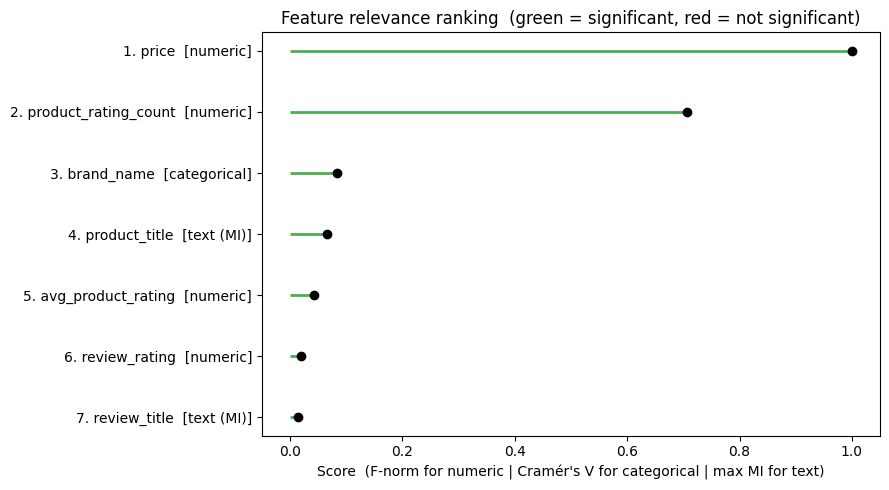

In [29]:
# ═══════════════════════════════════════════════════════════════════════════════
# 4. FINAL SUMMARY TABLE  —  unified ranking across all feature types
# ═══════════════════════════════════════════════════════════════════════════════

# --- numeric: use F-statistic normalised to [0,1] as a comparable "score" ----
f_max = numeric_results["F-statistic"].max()
numeric_summary = pd.DataFrame({
    "feature":    numeric_results["feature"],
    "type":       "numeric",
    "score":      (numeric_results["F-statistic"] / f_max).round(4),   # relative F
    "raw_stat":   numeric_results["F-statistic"].astype(str) + " (F)",
    "p_value":    numeric_results["p_anova"],
    "significant": numeric_results["p_anova"] < 0.05,
    "note":       numeric_results["sig_anova"],
})

# --- categorical: use Cramér's V as score -----------------------------------
cat_summary = pd.DataFrame({
    "feature":    cat_results["feature"],
    "type":       "categorical",
    "score":      cat_results["cramers_v"],
    "raw_stat":   cat_results["chi2"].astype(str) + " (χ²)",
    "p_value":    cat_results["p_chi2"],
    "significant": cat_results["p_chi2"] < 0.05,
    "note":       cat_results["sig"],
})

# --- text: use max MI score; flag as significant if max_MI > 0.01 ------------
MI_THRESHOLD = 0.01
text_summary = pd.DataFrame({
    "feature":    text_mi_results["feature"],
    "type":       "text (MI)",
    "score":      text_mi_results["max_MI"],
    "raw_stat":   text_mi_results["mean_MI_top15"].astype(str) + " (mean MI)",
    "p_value":    np.nan,                          # MI has no p-value
    "significant": text_mi_results["max_MI"] > MI_THRESHOLD,
    "note":       text_mi_results["max_MI"].apply(
                      lambda v: f"high MI (>{MI_THRESHOLD})" if v > MI_THRESHOLD else "low MI"),
})

# --- merge & rank ------------------------------------------------------------
summary = (
    pd.concat([numeric_summary, cat_summary, text_summary], ignore_index=True)
    .sort_values("score", ascending=False)
    .reset_index(drop=True)
)
summary.index += 1   # rank starts at 1
summary.index.name = "rank"

print("══ FINAL SUMMARY ═══════════════════════════════════════════════════════")
print(summary[["feature","type","score","raw_stat","p_value","significant","note"]]
      .to_string())

# visualise: lollipop chart of scores
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#4CAF50" if s else "#F44336" for s in summary["significant"]]
y_pos  = range(len(summary))
ax.hlines(y_pos, 0, summary["score"], colors=colors, linewidth=2)
ax.plot(summary["score"], y_pos, "o", color="black", zorder=3)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(
    [f"{r}. {f}  [{t}]" for r, f, t in
     zip(summary.index, summary["feature"], summary["type"])]
)
ax.set_xlabel("Score  (F-norm for numeric | Cramér's V for categorical | max MI for text)")
ax.set_title("Feature relevance ranking  (green = significant, red = not significant)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


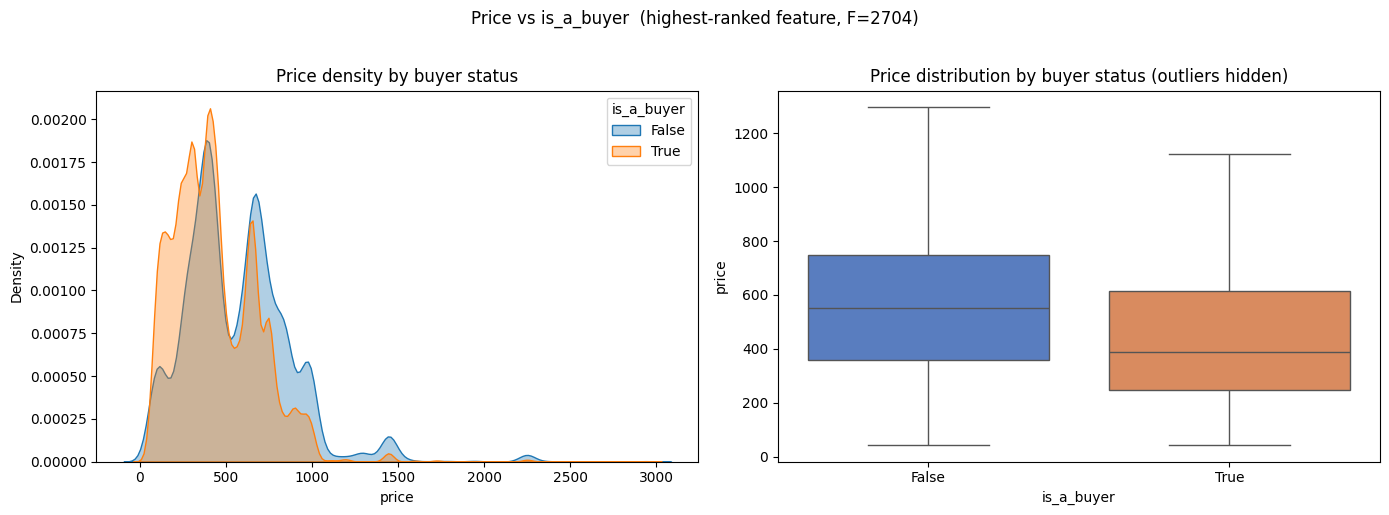

              count    mean     std   min    25%    50%    75%     max
is_a_buyer                                                            
False       13062.0  566.75  307.74  45.0  360.0  550.0  749.0  2947.0
True        48222.0  433.79  244.43  45.0  249.0  390.0  616.0  2947.0


In [30]:
# ═══════════════════════════════════════════════════════════════════════════════
# PRICE DISTRIBUTION  vs  is_a_buyer
# ═══════════════════════════════════════════════════════════════════════════════
df_price = df[["price", "is_a_buyer"]].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE — overlapping density curves per class
for label, grp in df_price.groupby("is_a_buyer"):
    sns.kdeplot(grp["price"], ax=axes[0], label=str(label), fill=True, alpha=0.35)
axes[0].set_title("Price density by buyer status")
axes[0].set_xlabel("price")
axes[0].legend(title="is_a_buyer")

# Box + strip — spread and median side-by-side
sns.boxplot(
    data=df_price, x="is_a_buyer", y="price",
    palette="muted", showfliers=False, ax=axes[1],
)
axes[1].set_title("Price distribution by buyer status (outliers hidden)")
axes[1].set_xlabel("is_a_buyer")

plt.suptitle("Price vs is_a_buyer  (highest-ranked feature, F=2704)", y=1.02)
plt.tight_layout()
plt.show()

# quick median summary
print(df_price.groupby("is_a_buyer")["price"].describe().round(2))


In [31]:
# ═══════════════════════════════════════════════════════════════════════════════
# BUILD df_final  —  7 significant features  +  review_vector (WEIGHTED_PATH)
# ═══════════════════════════════════════════════════════════════════════════════
from sklearn.preprocessing import OneHotEncoder

# ── 1. numeric columns (keep as scalar) ─────────────────────────────────────
NUMERIC_FINAL = ["price", "product_rating_count", "avg_product_rating", "review_rating"]

# ── 2. brand_name  →  one-hot encode, store as per-row vector ───────────────
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
brand_matrix = ohe.fit_transform(df[["brand_name"]].fillna("unknown"))
# one ndarray per row so prepare_train_data can expand it
brand_vectors = list(brand_matrix.astype(np.float32))

# ── 3. review_title & product_title  →  TF-IDF, store as per-row vector ─────
tfidf_title   = TfidfVectorizer(max_features=500, min_df=2, sublinear_tf=True)
tfidf_product = TfidfVectorizer(max_features=500, min_df=2, sublinear_tf=True)

review_title_matrix  = tfidf_title.fit_transform(
    df["review_title"].fillna("").astype(str)).toarray().astype(np.float32)
product_title_matrix = tfidf_product.fit_transform(
    df["product_title"].fillna("").astype(str)).toarray().astype(np.float32)

# ── 4. review_vector from WEIGHTED_PATH (already computed earlier) ───────────
review_vectors_weighted: np.ndarray = parse_review_vectors_txt(WEIGHTED_PATH)

# ── 5. assemble df_final ─────────────────────────────────────────────────────
df_final = df[NUMERIC_FINAL + ["is_a_buyer"]].copy().reset_index(drop=True)

# vector columns: each cell holds a 1-D ndarray → prepare_train_data expands them
df_final["vec_brand"]         = brand_vectors
df_final["vec_review_title"]  = list(review_title_matrix)
df_final["vec_product_title"] = list(product_title_matrix)
df_final["vec_review"]        = list(review_vectors_weighted)

print("df_final shape :", df_final.shape)
print("Columns        :", df_final.columns.tolist())
print("\nColumn dtypes:\n", df_final.dtypes)
print(f"\nVector dims  →  brand: {brand_matrix.shape[1]}"
      f"  |  review_title: {review_title_matrix.shape[1]}"
      f"  |  product_title: {product_title_matrix.shape[1]}"
      f"  |  review_vector: {review_vectors_weighted.shape[1]}")


df_final shape : (61284, 9)
Columns        : ['price', 'product_rating_count', 'avg_product_rating', 'review_rating', 'is_a_buyer', 'vec_brand', 'vec_review_title', 'vec_product_title', 'vec_review']

Column dtypes:
 price                     int64
product_rating_count      int64
avg_product_rating      float64
review_rating           float64
is_a_buyer                 bool
vec_brand                object
vec_review_title         object
vec_product_title        object
vec_review               object
dtype: object

Vector dims  →  brand: 11  |  review_title: 500  |  product_title: 500  |  review_vector: 300


In [32]:
# ═══════════════════════════════════════════════════════════════════════════════
# PREPARE TRAINING DATA  —  prepare_train_data on df_final
# ═══════════════════════════════════════════════════════════════════════════════
FEATURE_COLS = (
    NUMERIC_FINAL                                          # 4 scalar cols
    + ["vec_brand", "vec_review_title",                    # 2 text-vector cols
       "vec_product_title", "vec_review"]                  # + weighted review vec
)

X_final, y_final = prepare_train_data(df_final, FEATURE_COLS, "is_a_buyer")

print(f"X_final shape : {X_final.shape}")
print(f"y_final shape : {y_final.shape}  |  classes: {np.unique(y_final, return_counts=True)}")
print(f"\nFeature breakdown:")
print(f"  numeric                : {len(NUMERIC_FINAL)}")
print(f"  brand OHE              : {brand_matrix.shape[1]}")
print(f"  review_title TF-IDF    : {review_title_matrix.shape[1]}")
print(f"  product_title TF-IDF   : {product_title_matrix.shape[1]}")
print(f"  review_vector (weighted): {review_vectors_weighted.shape[1]}")
print(f"  ─────────────────────────────")
print(f"  total dims             : {X_final.shape[1]}")


X_final shape : (61284, 1315)
y_final shape : (61284,)  |  classes: (array([False,  True]), array([13062, 48222]))

Feature breakdown:
  numeric                : 4
  brand OHE              : 11
  review_title TF-IDF    : 500
  product_title TF-IDF   : 500
  review_vector (weighted): 300
  ─────────────────────────────
  total dims             : 1315


In [35]:
result: dict = run_kfold_balance_models(X_final, y_final, n_jobs=4, is_sanitize=False)


logistic_regression
  accuracy: nan ± nan
  f1: nan ± nan
  roc_auc: nan ± nan

random_forest
  accuracy: 0.8264 ± 0.0030
  f1: 0.8958 ± 0.0018
  roc_auc: 0.8784 ± 0.0032


Verdict

In [36]:
# Optimize

def _rf_estimator(n_jobs, random_state, svd_n_components):
    rf = RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=random_state,
        n_jobs=n_jobs,
    )
    if svd_n_components is None:
        return rf
    return make_pipeline(
        TruncatedSVD(n_components=svd_n_components, random_state=random_state),
        rf,
    )

def _lr_pipeline(n_jobs, random_state, svd_n_components):
    steps: list = []
    if svd_n_components is not None:
        steps.append(TruncatedSVD(n_components=svd_n_components, random_state=random_state))
    steps.extend([
        StandardScaler(),
        LogisticRegression(
            class_weight="balanced",
            solver="liblinear",
            max_iter=300,
            random_state=random_state,
        ),
    ])
    return make_pipeline(*steps)


def _lr_weight_pipeline(n_jobs, random_state, svd_n_components, class_weight):
    steps: list = []
    if svd_n_components is not None:
        steps.append(TruncatedSVD(n_components=svd_n_components, random_state=random_state))
    steps.extend([
        StandardScaler(),
        LogisticRegression(
            class_weight=class_weight,
            solver="liblinear",
            max_iter=300,
            random_state=random_state,
        ),
    ])
    return make_pipeline(*steps)


def _rf_weight_estimator(n_jobs, random_state, svd_n_components, class_weight):
    rf = RandomForestClassifier(
        n_estimators=100,
        class_weight=class_weight,
        random_state=random_state,
        n_jobs=n_jobs,
    )
    if svd_n_components is None:
        return rf
    return make_pipeline(
        TruncatedSVD(n_components=svd_n_components, random_state=random_state),
        rf,
    )


def run_kfold_balance_models(
    X,
    y,
    n_splits=5,
    random_state=42,
    n_jobs=-1,
    is_sanitize=True,
    model_names: list[str] | None = None,
    svd_n_components: int | None = None,
):
    """Stratified CV. If ``svd_n_components`` is set, ``TruncatedSVD`` runs inside each fold
    (fit on train split only — no leakage). Works with sparse count matrices.
    """
    if is_sanitize:
        X, y = sanitize_X_y(X, y)
    y = np.asarray(y).astype(int).reshape(-1)

    if model_names is None:
        model_names = ["logistic_regression", "random_forest"]

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    scoring = {"accuracy": "accuracy", "f1": "f1", "roc_auc": "roc_auc"}

    estimators_all = {
        "logistic_regression": _lr_pipeline(n_jobs, random_state, svd_n_components),
        "random_forest": _rf_estimator(n_jobs, random_state, svd_n_components),
    }
    unknown = set(model_names) - set(estimators_all)
    if unknown:
        raise ValueError(f"Unknown model_names: {unknown}")

    results = {}
    for name in model_names:
        model = estimators_all[name]
        use_scoring = svc_scoring if name == "svm_linear" else scoring
        res = cross_validate(model, X, y, cv=cv, scoring=use_scoring, n_jobs=n_jobs, return_train_score=False)
        results[name] = res

    for name, res in results.items():
        print(f"\n{name}")
        for k, v in res.items():
            if k.startswith("test_"):
                print(f"  {k[5:]}: {v.mean():.4f} ± {v.std():.4f}")

    return results

In [37]:
result: dict = run_kfold_balance_models(X_final, y_final, n_jobs=4, is_sanitize=False, model_names=["random_forest"])


random_forest
  accuracy: 0.8268 ± 0.0029
  f1: 0.8964 ± 0.0017
  roc_auc: 0.8805 ± 0.0028
